«Utilizaremos los modelos proporcionados por EleutherAI, una organización que comenzó como un modesto servidor de Discord para debatir sobre la alineación de modelos de lenguaje (LLMs). Desde entonces, el proyecto evolucionó hasta consolidarse como un referente en el desarrollo de modelos abiertos y la investigación en interpretabilidad mecanicista».

### Habra dos versiones de este modelo

In [1]:
# Alicia en el país de las Maravillas (A través del espejo) - Edgar Allan Poe (relatos cortos, escritos y poemas)

In [2]:
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
)  # Importa clases para cargar modelos de lenguaje y tokenizadores desde Hugging Face

import torch  # Núcleo principal de PyTorch para el manejo de tensores y cálculo en GPU
import torch.nn as nn  # Submódulo de PyTorch para la construcción de redes neuronales
import numpy as np  # Librería para cálculo numérico y manejo eficiente de arreglos
import matplotlib.pyplot as plt  # Librería para graficar curvas de pérdida y métricas

!pip install torchinfo  # Instala la librería para inspeccionar la arquitectura de modelos
from torchinfo import (
    summary,
)  # Importa la función summary para ver detalles de las capas de la red

import requests  # Librería para realizar peticiones HTTP de forma sencilla

## Cargar el modelo

In [3]:
# Tokenizador de Eleuther
tokenizer = AutoTokenizer.from_pretrained('EleutherAI/gpt-neo-125m')
tokenizer.pad_token_id = tokenizer.encode(' ')[0] #colocamos el eos como un espacio

# Cargar dos GPT-neo y enviarlos a la GPU
modelAlice = AutoModelForCausalLM.from_pretrained('EleutherAI/gpt-neo-125m') # modelo alicia
modelEdgar = AutoModelForCausalLM.from_pretrained('EleutherAI/gpt-neo-125m') # modelo Edgar

# -> GPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
modelAlice = modelAlice.to(device)
modelEdgar = modelEdgar.to(device)

Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

[transformers] GPTNeoForCausalLM LOAD REPORT from: EleutherAI/gpt-neo-125m
Key                                                   | Status     |  | 
------------------------------------------------------+------------+--+-
transformer.h.{0, 2, 4, 6, 8, 10}.attn.attention.bias | UNEXPECTED |  | 
transformer.h.{0...11}.attn.attention.masked_bias     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/160 [00:00<?, ?it/s]

[transformers] GPTNeoForCausalLM LOAD REPORT from: EleutherAI/gpt-neo-125m
Key                                                   | Status     |  | 
------------------------------------------------------+------------+--+-
transformer.h.{0, 2, 4, 6, 8, 10}.attn.attention.bias | UNEXPECTED |  | 
transformer.h.{0...11}.attn.attention.masked_bias     | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Visualización del modelo

In [4]:
# inspeccion del modelo

modelAlice

GPTNeoForCausalLM(
  (transformer): GPTNeoModel(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(2048, 768)
    (drop): Dropout(p=0.0, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPTNeoBlock(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPTNeoAttention(
          (attention): GPTNeoSelfAttention(
            (attn_dropout): Dropout(p=0.0, inplace=False)
            (resid_dropout): Dropout(p=0.0, inplace=False)
            (k_proj): Linear(in_features=768, out_features=768, bias=False)
            (v_proj): Linear(in_features=768, out_features=768, bias=False)
            (q_proj): Linear(in_features=768, out_features=768, bias=False)
            (out_proj): Linear(in_features=768, out_features=768, bias=True)
          )
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPTNeoMLP(
          (c_fc): Linear(in_features=768, out_features=3072, bias=True)
          (c_proj): Linear(in_fe

In [5]:
# Acceder a una matriz particular de pesos

modelAlice.transformer.h[3].attn.attention.k_proj.weight.shape

torch.Size([768, 768])

In [6]:
#pesos del bloque 3
modelAlice.transformer.h[3].attn.attention.k_proj.weight

Parameter containing:
tensor([[ 0.0293,  0.1377, -0.2773,  ...,  0.3770,  0.0603,  0.1289],
        [ 0.6133,  0.0420,  0.6992,  ..., -0.0508,  0.0146,  0.5195],
        [ 0.3750, -0.0383,  0.2676,  ...,  0.0165,  0.1562,  0.1445],
        ...,
        [-0.2520,  0.3047, -0.2031,  ..., -0.1240, -0.3184, -0.4668],
        [ 0.4629,  0.2295, -0.0962,  ...,  0.0308, -0.3066, -0.0918],
        [ 0.2949, -0.2021,  0.0065,  ...,  0.1064,  0.2324,  0.5352]],
       device='cuda:0', requires_grad=True)

In [7]:
#bloque 6 sin la final linear

modelAlice.transformer.h[6]

GPTNeoBlock(
  (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (attn): GPTNeoAttention(
    (attention): GPTNeoSelfAttention(
      (attn_dropout): Dropout(p=0.0, inplace=False)
      (resid_dropout): Dropout(p=0.0, inplace=False)
      (k_proj): Linear(in_features=768, out_features=768, bias=False)
      (v_proj): Linear(in_features=768, out_features=768, bias=False)
      (q_proj): Linear(in_features=768, out_features=768, bias=False)
      (out_proj): Linear(in_features=768, out_features=768, bias=True)
    )
  )
  (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  (mlp): GPTNeoMLP(
    (c_fc): Linear(in_features=768, out_features=3072, bias=True)
    (c_proj): Linear(in_features=3072, out_features=768, bias=True)
    (act): NewGELUActivation()
    (dropout): Dropout(p=0.0, inplace=False)
  )
)

In [8]:
# Resumen del modelo
x = tokenizer.encode(
    "What did the Red Queen say to Alice?", return_tensors="pt"
).to(
    device
)  # Codifica una frase de prueba relacionada con Alicia y la convierte en tensores para el dispositivo
summary(
    modelAlice,
    input_data=x,
    col_names=["input_size", "output_size", "num_params"],
)  # Genera un reporte detallado de la arquitectura de modelAlice usando torchinfo

Layer (type:depth-idx)                                  Input Shape               Output Shape              Param #
GPTNeoForCausalLM                                       [1, 9]                    --                        --
├─GPTNeoModel: 1-1                                      [1, 9]                    --                        --
│    └─Embedding: 2-1                                   [1, 9]                    [1, 9, 768]               38,597,376
│    └─Embedding: 2-2                                   [1, 9]                    [1, 9, 768]               1,572,864
│    └─Dropout: 2-3                                     [1, 9, 768]               [1, 9, 768]               --
│    └─ModuleList: 2-4                                  --                        --                        --
│    │    └─GPTNeoBlock: 3-1                            [1, 9, 768]               [1, 9, 768]               7,085,568
│    │    └─GPTNeoBlock: 3-2                            [1, 9, 768]               [1,

### ¿Están vinculadas las matrices de Embedding y Unembedding?

El objetivo de esta validación es comprobar si la matriz de incrustación inicial (entrada) es exactamente la misma que la matriz de salida (`lm_head`).

* **Método riguroso:** Si se requiriera una cuantificación precisa, lo ideal sería restar ambas matrices y verificar si alguno de los valores difiere de cero, o bien calcular la norma de la matriz de diferencias para comprobar si es estrictamente igual a cero.
* **Aproximación práctica:** En este ejemplo realizamos una comprobación directa y visual para determinar si ambas estructuras coinciden. Esto nos permite entender cómo están diseñadas las capas en los modelos de EleutherAI, donde los pesos de entrada (`embeddings`) y de salida (`unembeddings`) se encuentran compartidos o vinculados (*tied weights*).

In [9]:
# ¿Están los pesos de embedding y unembedding vinculados (tied)?
print(
    "** Embedding:\n", modelAlice.transformer.wte.weight.detach()
)  # Imprime la matriz de pesos de incrustación (token embeddings) del modelo
print(
    "\n** Unembedding:\n", modelAlice.lm_head.weight.detach()
)  # Imprime la matriz de pesos de la cabeza del lenguaje (salida / unembedding)

** Embedding:
 tensor([[ 0.1709, -0.7383,  0.4277,  ...,  0.0840,  0.5820, -0.3457],
        [ 0.2070, -0.6055,  0.4590,  ...,  0.1562,  0.4883, -0.2363],
        [ 0.2324, -0.6367,  0.3262,  ...,  0.2236,  0.7500, -0.2354],
        ...,
        [ 0.7734, -1.1406,  0.6523,  ...,  0.2832,  0.9258, -0.5547],
        [ 0.3906, -0.8438,  0.5117,  ...,  0.0148,  0.6992, -0.2383],
        [ 0.2734, -0.7148,  0.2949,  ...,  0.1748,  0.4043, -0.3105]],
       device='cuda:0')

** Unembedding:
 tensor([[ 0.1709, -0.7383,  0.4277,  ...,  0.0840,  0.5820, -0.3457],
        [ 0.2070, -0.6055,  0.4590,  ...,  0.1562,  0.4883, -0.2363],
        [ 0.2324, -0.6367,  0.3262,  ...,  0.2236,  0.7500, -0.2354],
        ...,
        [ 0.7734, -1.1406,  0.6523,  ...,  0.2832,  0.9258, -0.5547],
        [ 0.3906, -0.8438,  0.5117,  ...,  0.0148,  0.6992, -0.2383],
        [ 0.2734, -0.7148,  0.2949,  ...,  0.1748,  0.4043, -0.3105]],
       device='cuda:0')


In [10]:
# Un poco sobre su tokenizador
print(f"Tokenizer has {tokenizer.vocab_size:,} tokens.\nA few random tokens:\n")
for i in range(30):
  # generar un token aleatorio
  randtok = torch.randint(tokenizer.vocab_size, (1,))
  print(f'Token {randtok[0]:5} is "{tokenizer.decode(randtok)}"')

[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Tokenizer has 50,257 tokens.
A few random tokens:

Token  8148 is " respectively"
Token 12008 is " scared"
Token 40170 is " spraying"
Token 30860 is " chalk"
Token 40557 is " satirical"
Token 38865 is "FAULT"
Token 46446 is " Churches"
Token 21405 is " bark"
Token 15953 is " Gates"
Token 26056 is " fireworks"
Token 26263 is "reported"
Token 42853 is " moss"
Token 38622 is " disturbances"
Token 46275 is " snowball"
Token 31804 is " peppers"
Token 17092 is " privately"
Token 26834 is " waved"
Token 46670 is "trap"
Token 25477 is " contingent"
Token 21643 is " 137"
Token 28503 is " Lomb"
Token 45525 is "together"
Token 37790 is " Cham"
Token 47370 is " convoluted"
Token 26028 is " Rings"
Token  8560 is " advertising"
Token 11637 is " borders"
Token 12005 is " Fle"
Token  1635 is " *"
Token 13534 is "LA"


In [11]:
# verificar la forma de la salida en bruto
into = tokenizer.encode(
    "What did the Red Queen say to Alice?", return_tensors="pt"
).to(
    device
)  # Codifica la frase de prueba y la envía al dispositivo configurado (GPU/CPU)

out = modelAlice(into)
print(
    out.logits.shape
)  # [batch, tokens, embedding] - Pasa la entrada por el modelo y muestra las dimensiones del tensor de logits resultante

torch.Size([1, 9, 50257])


In [12]:
# text generation
out = modelAlice.generate(into,max_new_tokens=120,do_sample=True,pad_token_id=50256)
print(tokenizer.decode(out[0].cpu()))

What did the Red Queen say to Alice?

The Red Queen's voice came out of the backseat of Alice's car as she heard Mr. Crichton in the background and what was going on out there. The red-haired lady said, "Look, Alice, you need to know that I have nothing to say about it," and she and I went into the police station and gave Mr. Crichton a number on the box. We watched Alice go back into the police wing and go back into the police station.

Alice and Mr. Crichton went to Miss Harkinson's house. They said


#### Comparación (es el mismo tokenizador)

In [13]:
# ¿Es diferente del tokenizador de GPT?
from transformers import GPT2Tokenizer

gptTokenizer = GPT2Tokenizer.from_pretrained("gpt2")

Donde la (e) es Eleuther - y (g) es GPT

In [14]:
for i in range(30):
  # generar un token aleatorio
  randtok = torch.randint(tokenizer.vocab_size, (1,))

  # obtener el texto del token para ambos tokenizadores
  e = tokenizer.decode(randtok)
  g = gptTokenizer.decode(randtok)
  print(f'Token {randtok[0]:5} is "{e}" and "{g}"')

Token 14295 is "Jack" and "Jack"
Token 34118 is " Cait" and " Cait"
Token 43056 is "abiding" and "abiding"
Token 38309 is " convict" and " convict"
Token 36977 is "netflix" and "netflix"
Token 37086 is " regimen" and " regimen"
Token  7665 is ";;" and ";;"
Token 23630 is " insisting" and " insisting"
Token 50234 is " gazing" and " gazing"
Token 45346 is "BUS" and "BUS"
Token 49299 is " allowable" and " allowable"
Token 32081 is " insignificant" and " insignificant"
Token 47779 is "examination" and "examination"
Token 14990 is "TL" and "TL"
Token  3265 is " population" and " population"
Token 21224 is " ROM" and " ROM"
Token 19144 is " uploaded" and " uploaded"
Token 30062 is "quist" and "quist"
Token 28625 is " heir" and " heir"
Token 35240 is " Parish" and " Parish"
Token 32869 is "704" and "704"
Token 34514 is " overth" and " overth"
Token  6430 is " Yet" and " Yet"
Token 39375 is " Poc" and " Poc"
Token 46294 is " Panzer" and " Panzer"
Token 25324 is "Japanese" and "Japanese"
Token 

## Importar los textos y procesarlos

El libro de Lewis Carnoll es solo un libro por lo tanto hay mas diversidad en los textos variados de Poe

In [15]:
# A través del espejo (también conocido como Alicia en el país de las maravillas)
text = requests.get(
    "https://www.gutenberg.org/cache/epub/11/pg11.txt"
).text
aliceTokens = torch.tensor(tokenizer.encode(text), dtype=torch.long)

# Edgar Allan Poe
text = requests.get(
    "https://www.gutenberg.org/cache/epub/2148/pg2148.txt"
).text
edgarTokens = torch.tensor(tokenizer.encode(text), dtype=torch.long)

# Resumen
print(f"Alice in Wonderland has   {len(aliceTokens):7,} tokens.")
print(f"Edgar Allan Poe text has {len(edgarTokens):7,} tokens.")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (52948 > 2048). Running this sequence through the model will result in indexing errors


Alice in Wonderland has    52,948 tokens.
Edgar Allan Poe text has 197,302 tokens.


## Preparación para el Finetunning

In [16]:
# ALICE optimizador
optimizerAlice = torch.optim.AdamW(modelAlice.parameters(), lr=5e-5, weight_decay=.01)

# EDGAR optimizador
optimizerEdgar = torch.optim.AdamW(modelEdgar.parameters(), lr=5e-5, weight_decay=.01)

In [17]:
# Parámetros de entrenamiento
seq_len = 256  # Longitud máxima de secuencia
batch_size = 16
num_samples = 476

## Finetune - El modelo

En hugginface no necesitamos una funcion de perdida a parte / ya esta proporcionada

In [18]:
# Inicializar arreglos para registrar las pérdidas (losses)
lossAlice = np.zeros(num_samples)
lossEdgar = np.zeros(num_samples)

# Bucle principal de entrenamiento
for sampli in range(num_samples):

  ### - Fine-tuning de ALICE
  # Obtener un lote de datos aleatorio
  ix = torch.randint(len(aliceTokens) - seq_len, size=(batch_size,))
  X = aliceTokens[ix[:, None] + torch.arange(seq_len)].to(device)

  # Pasada hacia adelante (forward pass) y cálculo de la pérdida
  modelAlice.zero_grad()
  outputs = modelAlice(X, labels=X)

  # Retropropagación, actualización de pesos y almacenamiento de la pérdida
  outputs.loss.backward()
  optimizerAlice.step()
  lossAlice[sampli] = outputs.loss.item()
  ### ---------------------

  ### - Fine-tuning de EDGAR
  # Obtener un lote de datos aleatorio
  ix = torch.randint(len(edgarTokens) - seq_len, size=(batch_size,))
  X = edgarTokens[ix[:, None] + torch.arange(seq_len)].to(device)

  # Pasada hacia adelante (forward pass) y cálculo de la pérdida
  modelEdgar.zero_grad()
  outputs = modelEdgar(X, labels=X)

  # Retropropagación, actualización de pesos y almacenamiento de la pérdida
  outputs.loss.backward()
  optimizerEdgar.step()
  lossEdgar[sampli] = outputs.loss.item()
  ### ---------------------

  # Actualizar y mostrar el progreso del entrenamiento en intervalos regulares
  if sampli % 77 == 0:
    print(
        f"Sample {sampli:4}/{num_samples}, losses (Alice/Edgar):"
        f" {lossAlice[sampli]:.2f}/{lossEdgar[sampli]:.2f}"
    )

Sample    0/476, losses (Alice/Edgar): 2.77/2.67
Sample   77/476, losses (Alice/Edgar): 1.80/2.21
Sample  154/476, losses (Alice/Edgar): 1.13/2.11
Sample  231/476, losses (Alice/Edgar): 0.70/1.82
Sample  308/476, losses (Alice/Edgar): 0.50/1.84
Sample  385/476, losses (Alice/Edgar): 0.27/1.55
Sample  462/476, losses (Alice/Edgar): 0.23/1.47


## Visualización

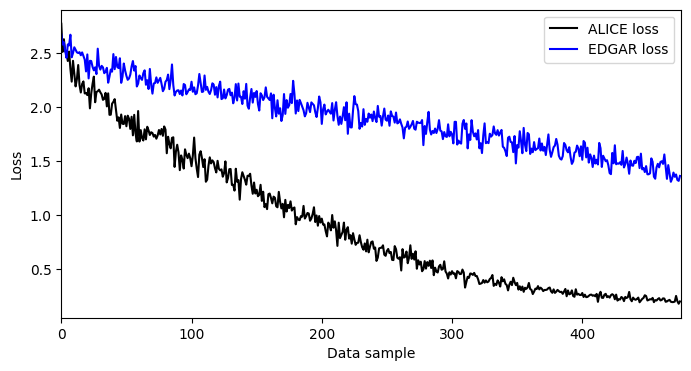

In [19]:
# plot the losses
plt.figure(figsize=(8,4))
plt.plot(lossAlice,'k',markersize=8,label='ALICE loss')
plt.plot(lossEdgar,'b',markersize=8,label='EDGAR loss')

plt.legend()
plt.gca().set(xlabel='Data sample',ylabel='Loss',xlim=[0,num_samples])
plt.show()

---

### Análisis de convergencia y estilo literario

El texto de *Alicia en el país de las maravillas* presenta una estructura narrativa más homogénea en términos de vocabulario y tono, lo que facilita una adaptación y un aprendizaje más rápidos para el modelo.

Por el contrario, la obra de Edgar Allan Poe resulta considerablemente más heterogénea. Su estilo literario, marcado por la prosa del siglo XIX, la densidad psicológica y una sintaxis más compleja, difiere marcadamente de los patrones lingüísticos presentes en internet que conformaron el preentrenamiento original del modelo (como Wikipedia, artículos de noticias o foros como Reddit). Esta divergencia estilística se refleja de manera directa en la evolución de las métricas de pérdida durante el ajuste fino (*fine-tuning*).

## Análisis Cualitativo

In [22]:
# Entrada de texto
x = tokenizer.encode(
    'What did the Red Queen say to Alice?', return_tensors='pt'
).to(device)

# Generar texto con ambos modelos
outAlice = modelAlice.generate(
    x, max_new_tokens=120, do_sample=True, pad_token_id=50256
)
outEdgar = modelEdgar.generate(
    x, max_new_tokens=120, do_sample=True, pad_token_id=50256
)

# Imprimir las respuestas generadas por cada modelo
print('** Alice model says:')
print(tokenizer.decode(outAlice[0].cpu()))
print('\n\n** Edgar model says:')
print(tokenizer.decode(outEdgar[0].cpu()))

** Alice model says:
What did the Red Queen say to Alice?”

“Not about _what_?” said Alice in a relieved tone.

“Nothing,” said the March Hare.

Alice felt dreadfully puzzled, As it seemed the Hare had never meant
before to speak to her, And she did not know what to say to this: “No
how,” she said.

“How doth the Rabbit?” said the March Hare.

“Who sent the Mouse?” said


** Edgar model says:
What did the Red Queen say to Alice? Do you remember her name?”

      “No; she knew, by name, the Prince Prospero of Carabas, the
      Marches of Zola, the daughter of the Amontillado, and the wife of
      his confessor, Calipo.”

      “Then who did these things for you?”

      “I did not have to become a court


### Conclusión

El experimento demuestra de forma clara cómo el ajuste fino (*fine-tuning*) con un volumen reducido de muestras es capaz de inclinar el comportamiento estilístico de un modelo de lenguaje general.

* **Especialización temática:** A pesar de partir de un mismo modelo base (`gpt-neo-125m`) y recibir el mismo estímulo inicial (*prompt*), las dos instancias divergence de manera notable según el corpus de entrenamiento asignado.

* **Reflejo del estilo literario:**
* `modelAlice` adopta con naturalidad el tono de los diálogos absurdos, los personajes entrañables y la estructura de preguntas y respuestas caóticas típica de Lewis Carroll.

* `modelEdgar` reinterpreta la consigna introduciendo referencias a un imaginario más oscuro y recargado, evocando la atmósfera lúgubre, los nombres señoriales y la tensión psicológica característica de la obra de Edgar Allan Poe.


* **Implicaciones prácticas:** Este enfoque de "gemelos de entrenamiento" confirma que las arquitecturas modernas de transformadores responden con gran sensibilidad al sesgo literario de los datos, permitiendo modular la personalidad y la voz narrativa de un modelo con un coste computacional sumamente accesible.